In [3]:

from jsonschema import validate
from jsonschema.exceptions import ValidationError
import json

from src.pipeline.ml.context_extractor.utils.helpers.seed_utils import enforce_reproducibility
from src.pipeline.ml.context_extractor.utils.data.data_preprocessor import prepare_data
from src.pipeline.ml.context_extractor.utils.training_pipeline_utils import train_model

import logging

logger = logging.getLogger(__name__)


activity_recognition_config_path = "config/machine-activity-recognition/machine-activity-recognition-config.json"
activity_recognition_config_schema_path = "config/machine-activity-recognition/machine-activity-recognition-config-schema.json"
        
context_extraction_config_path = "config/context-extraction/context-extraction-config.json"
context_extraction_config_schema_path = "config/context-extraction/context-extraction-config-schema.json"

spring_back_config_path = "config/springback-prediction/springback-prediction-config.json"

def get_schema_description(schema_part, path):
    """Traverse schema to find 'description' for a given path."""
    for key in path:
        if 'properties' in schema_part and key in schema_part['properties']:
            schema_part = schema_part['properties'][key]
        else:
            return None
    return schema_part.get('description')

with open(context_extraction_config_path, "r") as f:
    config = json.load(f)
with open(context_extraction_config_schema_path, "r") as f:
    schema = json.load(f)

try:
    validate(instance=config, schema=schema)
    logging.info("Configuration json is valid!")
except ValidationError as e:
    path_list = list(e.path)
    description = get_schema_description(schema, path_list)
    
    if description:
        message = f"Validation failed at '{' -> '.join(str(p) for p in path_list)}': {description}"
    else:
        message = f"Validation failed at '{' -> '.join(str(p) for p in path_list)}': {e.message}"
    
    logging.error(message)


input_path_param = config.get("inputPathParams")
preprocessing_param = config.get("preprocessingParams")
training_params = config.get("trainingParams")
occlusion_params = config.get("occlusionParams")
preprocessing_info = config.get("preprocessingParams")
seed = config.get("generalSetting").get("seed", 42)

process_part = input_path_param.get("process_part")


# ============================================================
# Seeding for reproducibility
# ============================================================
enforce_reproducibility(seed=seed)

# ============================================================
# Read and preprocess data
# ============================================================
(
X_train, Y_train, X_test, Y_test, 
springbacks_train, springbacks_test, 
experiment_configurations_train, experiment_configurations_test, 
sensor_names, target_feature_names, annot_timesteps, 
mandrel_extraction_annot_timesteps, normalization_info
) = prepare_data(
input_path_param=input_path_param,
preprocessing_param=preprocessing_param,
)


2026-01-23 20:41:36 | ERROR | <module> | Validation failed at 'trainingParams': Additional properties are not allowed ('feature_loss_types' was unexpected)
2026-01-23 20:41:36 | INFO | wrapper | Entering load_all_data_from_sqlite
2026-01-23 20:41:41 | INFO | wrapper | Finishing load_all_data_from_sqlite


In [4]:
print(f"X_train: {X_train.shape}\nY_train: {Y_train.shape}\nX_test: {X_test.shape}\nY_test: {Y_test.shape}")

X_train: torch.Size([260, 400, 13])
Y_train: torch.Size([260, 45, 1])
X_test: torch.Size([141, 400, 13])
Y_test: torch.Size([141, 45, 1])


In [5]:
# ============================================================
# 0. NORMALIZATION (Important)
# ============================================================

def normalize_X(X_train, X_val):
    """
    Normalize input sequences feature-wise.

    X shape: (N,T,F)
    Normalization over N*T for each feature.
    """

    mean = X_train.mean(dim=(0, 1), keepdim=True)   # (1,1,F)
    std  = X_train.std(dim=(0, 1), keepdim=True)    # (1,1,F)

    X_train_norm = (X_train - mean) / (std + 1e-8)
    X_val_norm   = (X_val   - mean) / (std + 1e-8)

    return X_train_norm, X_val_norm, mean, std


def normalize_Y(Y_train, Y_val):
    """
    Normalize regression targets.

    Y shape: (N,A,O)
    Normalization over N*A for each output dimension.
    """

    mean = Y_train.mean(dim=(0, 1), keepdim=True)   # (1,1,O)
    std  = Y_train.std(dim=(0, 1), keepdim=True)    # (1,1,O)

    Y_train_norm = (Y_train - mean) / (std + 1e-8)
    Y_val_norm   = (Y_val   - mean) / (std + 1e-8)

    return Y_train_norm, Y_val_norm, mean, std


Using device: cpu


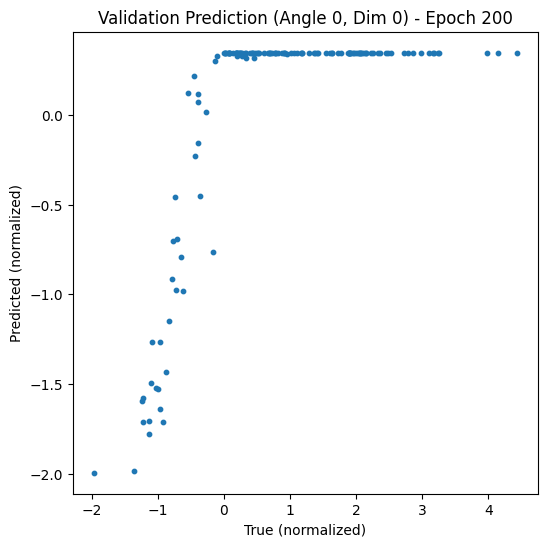

Training:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 001 | Train=1.010580 | Val=0.785280


Training:   0%|          | 1/200 [00:03<10:04,  3.04s/it]

Epoch 002 | Train=1.004611 | Val=0.791305


Training:   1%|          | 2/200 [00:06<09:55,  3.01s/it]

...

Epoch 199 | Train=0.384936 | Val=0.250202


Training: 100%|█████████▉| 199/200 [09:29<00:01,  1.60s/it]

Epoch 200 | Train=0.383077 | Val=0.253646


Training: 100%|██████████| 200/200 [09:30<00:00,  2.85s/it]


Training finished. Best Val Loss = 0.23881897081931433
Pred (denormalized) shape: torch.Size([1, 45, 1])


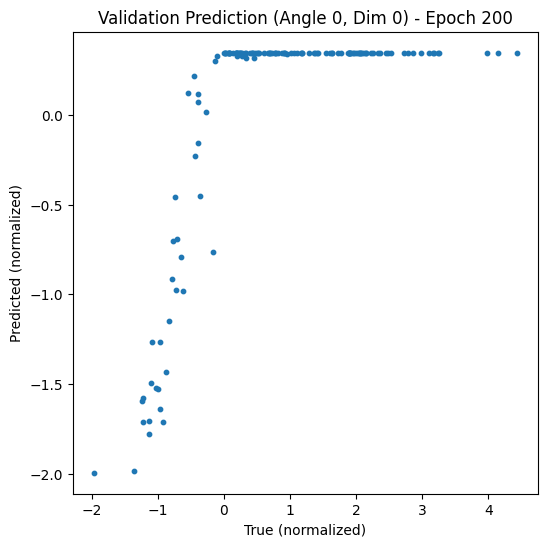

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# 0. NORMALIZATION HELPERS
# ============================================================
def normalize_X(X_train: torch.Tensor, X_val: torch.Tensor, eps: float = 1e-8):
    """
    Feature-wise normalization for X over (N,T).

    X shape: (N,T,F)
    mean/std: (1,1,F)
    """
    if X_train.dim() != 3 or X_val.dim() != 3:
        raise ValueError("X_train and X_val must be (N,T,F)")

    mean = X_train.mean(dim=(0, 1), keepdim=True)
    std = X_train.std(dim=(0, 1), keepdim=True)

    X_train_norm = (X_train - mean) / (std + eps)
    X_val_norm = (X_val - mean) / (std + eps)

    return X_train_norm, X_val_norm, mean, std


def normalize_Y(Y_train: torch.Tensor, Y_val: torch.Tensor, eps: float = 1e-8):
    """
    Feature-wise normalization for Y over (N,A).

    Y shape: (N,A,O)
    mean/std: (1,1,O)
    """
    if Y_train.dim() != 3 or Y_val.dim() != 3:
        raise ValueError("Y_train and Y_val must be (N,A,O)")

    mean = Y_train.mean(dim=(0, 1), keepdim=True)
    std = Y_train.std(dim=(0, 1), keepdim=True)

    Y_train_norm = (Y_train - mean) / (std + eps)
    Y_val_norm = (Y_val - mean) / (std + eps)

    return Y_train_norm, Y_val_norm, mean, std


def denormalize_Y(Y_norm: torch.Tensor, Y_mean: torch.Tensor, Y_std: torch.Tensor, eps: float = 1e-8):
    """
    Inverse transform for normalized predictions.

    Y_norm: (..., A, O) or (..., O) broadcastable with (1,1,O)
    """
    return Y_norm * (Y_std + eps) + Y_mean


# ============================================================
# 1. MLP ATTENTION
# ============================================================
class MLPAttention(nn.Module):
    """
    Multi-step attention mechanism.

    Each prediction index (angle) has its own learnable embedding vector,
    enabling different attention focus per output.
    """

    def __init__(self, n_predictions: int, hidden_dim: int = 128):
        super().__init__()
        self.n_predictions = n_predictions

        # Learnable embeddings per prediction step
        self.angle_embeddings = nn.Parameter(torch.randn(n_predictions, hidden_dim))

        # Attention MLP -> scalar score per timestep
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

        nn.init.xavier_uniform_(self.angle_embeddings)

    def forward(self, H: torch.Tensor):
        """
        H: (B,T,D)

        Returns:
            contexts: (B,A,D)
            attns:    (B,A,T)
        """
        if H.dim() != 3:
            raise ValueError(f"H must be (B,T,D), got {H.shape}")

        B, T, D = H.shape
        contexts = []
        attns = []

        for a in range(self.n_predictions):
            scores = self.mlp(H + self.angle_embeddings[a]).squeeze(-1)  # (B,T)
            w = torch.softmax(scores, dim=-1)  # (B,T)
            ctx = (w.unsqueeze(-1) * H).sum(dim=1)  # (B,D)
            contexts.append(ctx)
            attns.append(w)

        return torch.stack(contexts, dim=1), torch.stack(attns, dim=1)


# ============================================================
# 2. ATTENTION CNN MODEL
# ============================================================
class AttentionCNN(nn.Module):
    def __init__(
        self,
        input_features: int,
        n_predictions: int,
        output_features: int = 1,
        hidden_dim: int = 128,
        conv_layers: int = 3,
        kernel_size: int = 3,
        dropout: float = 0.3,
    ):
        super().__init__()

        self.n_predictions = n_predictions

        layers = []
        for i in range(conv_layers):
            in_ch = input_features if i == 0 else hidden_dim
            layers.append(
                nn.Conv1d(
                    in_ch,
                    hidden_dim,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2,
                )
            )
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        self.conv = nn.Sequential(*layers)
        self.ln = nn.LayerNorm(hidden_dim)
        self.attention = MLPAttention(n_predictions, hidden_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, output_features),
        )

    def forward(self, x: torch.Tensor):
        """
        x: (B,T,F)

        Returns:
            out:  (B,A,O)
            attn: (B,A,T)
        """
        if x.dim() != 3:
            raise ValueError(f"x must be (B,T,F), got {x.shape}")

        o = x.transpose(1, 2)   # (B,F,T)
        o = self.conv(o)        # (B,H,T)
        o = o.transpose(1, 2)   # (B,T,H)
        o = self.ln(o)          # (B,T,H)

        ctx, attn = self.attention(o)  # ctx: (B,A,H), attn: (B,A,T)
        out = self.fc(ctx)             # (B,A,O)

        return out, attn


# ============================================================
# 3. DATASET
# ============================================================
class SequenceAngleDataset(Dataset):
    """
    X: (N,T,F)
    Y: (N,A,O)

    Returns:
        x: (T,F)
        y: (A,O)
    """

    def __init__(self, X: torch.Tensor, Y: torch.Tensor):
        if X.dim() != 3:
            raise ValueError("X must be (N,T,F)")
        if Y.dim() != 3:
            raise ValueError("Y must be (N,A,O)")
        if X.shape[0] != Y.shape[0]:
            raise ValueError("X and Y must match in N")

        self.X = X.float()
        self.Y = Y.float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


# ============================================================
# 4. EVALUATION
# ============================================================
@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    y_true_all = []
    y_pred_all = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        pred, attn = model(x)
        loss = loss_fn(pred, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_samples += bs

        y_true_all.append(y.detach().cpu())
        y_pred_all.append(pred.detach().cpu())

    return total_loss / max(1, total_samples), torch.cat(y_true_all), torch.cat(y_pred_all)


# ============================================================
# 5. TRAINING
# ============================================================
def train_attention_model(
    X_train, Y_train,
    X_val, Y_val,
    lr=1e-3,
    batch_size=16,
    epochs=200,
    patience=15,
    plot_every=10,
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = AttentionCNN(
        input_features=X_train.shape[-1],
        n_predictions=Y_train.shape[1],
        output_features=Y_train.shape[-1],
        hidden_dim=16,
        conv_layers=3,
        kernel_size=5,
        dropout=0.1
    ).to(device)

    train_loader = DataLoader(
        SequenceAngleDataset(X_train, Y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    val_loader = DataLoader(
        SequenceAngleDataset(X_val, Y_val),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_loss = float("inf")
    bad_epochs = 0
    best_state = None

    fig, ax = plt.subplots(figsize=(6, 6))
    plot_handle = display(fig, display_id=True)

    for epoch in tqdm(range(1, epochs + 1), desc="Training"):

        # ---------------- TRAIN ----------------
        model.train()
        train_loss_sum = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            pred, attn = model(x)
            loss = loss_fn(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * x.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        # ---------------- VAL ----------------
        val_loss, y_true, y_pred = evaluate(model, val_loader, loss_fn, device)

        print(f"Epoch {epoch:03d} | Train={train_loss:.6f} | Val={val_loss:.6f}")

        # ---------------- PLOT ----------------
        if plot_every and (epoch % plot_every == 0):
            ax.clear()
            # plot angle 0, output dim 0
            ax.scatter(y_true[:, 0, 0], y_pred[:, 0, 0], s=10)
            ax.set_title(f"Validation Prediction (Angle 0, Dim 0) - Epoch {epoch}")
            ax.set_xlabel("True (normalized)")
            ax.set_ylabel("Predicted (normalized)")
            plot_handle.update(fig)

        # ---------------- EARLY STOPPING ----------------
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("\nEarly stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    print("\nTraining finished. Best Val Loss =", best_loss)
    return model, device


# ============================================================
# 6. EXAMPLE USAGE (WITH NORMALIZATION)
# ============================================================

# Assumes you already have:
# X_train: (N,T,F)
# Y_train: (N,A,O)
# X_val:   (N,T,F)
# Y_val:   (N,A,O)

# Ensure float tensors
X_train = X_train.float()
Y_train = Y_train.float()
X_val   = X_test.float()
Y_val   = Y_test.float()

# Normalize (fit on train only)
X_train_n, X_val_n, X_mean, X_std = normalize_X(X_train, X_val)
Y_train_n, Y_val_n, Y_mean, Y_std = normalize_Y(Y_train, Y_val)

# Train on normalized data
model, device = train_attention_model(
    X_train_n, Y_train_n,
    X_val_n,   Y_val_n,
    lr=1e-4,
    batch_size=16,
    epochs=200,
    patience=15,
    plot_every=1,
)

# Example inference + denormalization
model.eval()
with torch.no_grad():
    x = X_val_n[0:1].to(device)      # (1,T,F)
    pred_n, attn = model(x)          # pred_n: (1,A,O)

pred = denormalize_Y(pred_n.cpu(), Y_mean, Y_std)  # (1,A,O)
print("Pred (denormalized) shape:", pred.shape)
